<a href="https://colab.research.google.com/github/abhishekanand04/DAV---Fundamentals/blob/fundamentals/Dec24_ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1n9268qSj_5Q7KS_ntpv-wFPQC1UyJh6f -O aerofit.csv

--2025-01-08 15:44:42--  https://drive.google.com/uc?id=1n9268qSj_5Q7KS_ntpv-wFPQC1UyJh6f
Resolving drive.google.com (drive.google.com)... 173.194.194.139, 173.194.194.138, 173.194.194.102, ...
Connecting to drive.google.com (drive.google.com)|173.194.194.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1n9268qSj_5Q7KS_ntpv-wFPQC1UyJh6f [following]
--2025-01-08 15:44:42--  https://drive.usercontent.google.com/download?id=1n9268qSj_5Q7KS_ntpv-wFPQC1UyJh6f
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 209.85.200.132, 2607:f8b0:4001:c16::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|209.85.200.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7461 (7.3K) [application/octet-stream]
Saving to: ‘aerofit.csv’

aerofit.csv         100%[===================>]   7.29K  --.-KB/s    in 0s      

2025-01-08 15:44:45 (19.5 MB/s) -

In [ ]:
df_aerofit = pd.read_csv('/content/aerofit.csv')

df_aerofit.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
df_aerofit["Product"].unique()

array(['KP281', 'KP481', 'KP781'], dtype=object)

<Axes: xlabel='Product', ylabel='Income'>

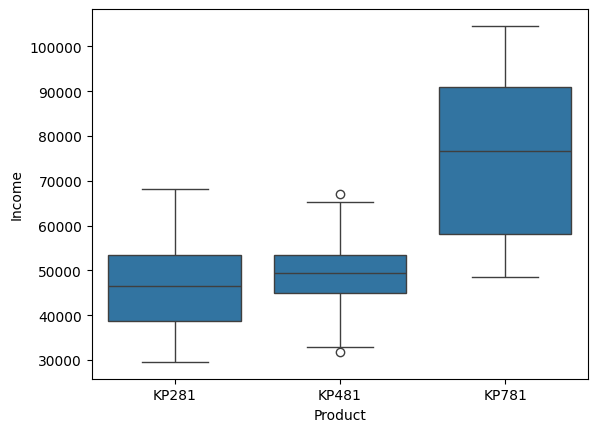

In [ ]:
sns.boxplot(x='Product', y='Income', data=df_aerofit)

In [ ]:
np.random.seed(42)
df_aerofit["random_group"] = np.random.choice(["g1", "g2", "g3"],size=len(df_aerofit))

df_aerofit.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,random_group
0,KP281,18,Male,14,Single,3,4,29562,112,g3
1,KP281,19,Male,15,Single,2,3,31836,75,g1
2,KP281,19,Female,14,Partnered,4,3,30699,66,g3
3,KP281,19,Male,12,Single,3,3,32973,85,g3
4,KP281,20,Male,13,Partnered,4,2,35247,47,g1


<Axes: xlabel='random_group', ylabel='Income'>

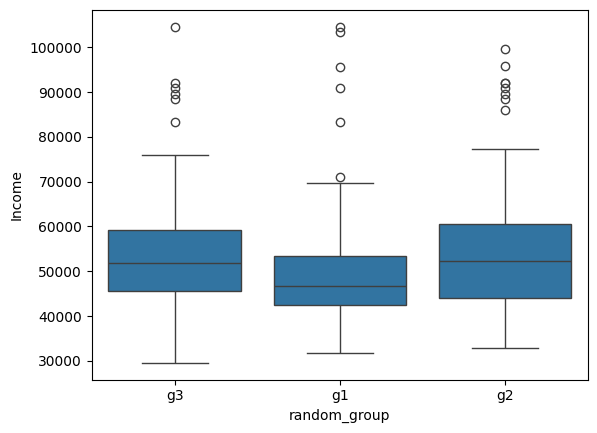

In [ ]:
sns.boxplot(x='random_group', y='Income', data=df_aerofit)

In [ ]:
from scipy.stats import f_oneway # Numeric Vs categorical for many categories
from scipy.stats import ttest_ind # Numeric Vs categorical

from statsmodels.graphics.gofplots import qqplot

<Axes: xlabel='random_group', ylabel='Income'>

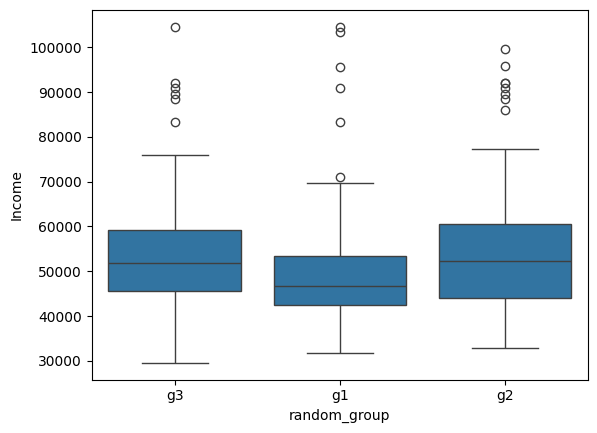

In [ ]:
sns.boxplot(x='random_group', y='Income', data=df_aerofit)

In [ ]:
income_g1 = df_aerofit[df_aerofit["random_group"]=="g1"]["Income"]
income_g2 = df_aerofit[df_aerofit["random_group"]=="g2"]["Income"]
income_g3 = df_aerofit[df_aerofit["random_group"]=="g3"]["Income"]

In [ ]:
income_g1.mean(), income_g2.mean(), income_g3.mean()

(51840.44827586207, 55812.69642857143, 53594.954545454544)

In [ ]:
# H0: All groups have the same mean
# Ha: One or more groups have different mean
f_stats, p_value = f_oneway(income_g1, income_g2, income_g3)

print("test statistic:",f_stats)
print("p_value:",p_value)

test statistic: 0.8263259710788367
p_value: 0.43933541801191467


In [ ]:
if p_value < 0.05:
    print("Reject H0")
    print("Atleast one group have different mean")
else:
    print("Fail to reject H0")
    print("All groups have same mean")

Fail to reject H0
All groups have same mean


<Axes: xlabel='Product', ylabel='Income'>

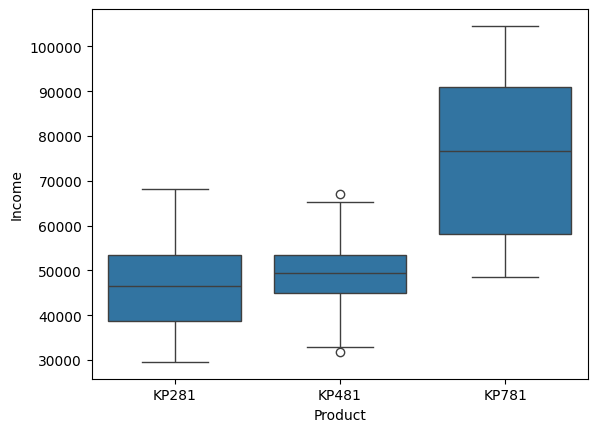

In [ ]:
sns.boxplot(x='Product', y='Income', data=df_aerofit)

In [ ]:
income_kp281 = df_aerofit[df_aerofit["Product"]=="KP281"]["Income"]
income_kp481 = df_aerofit[df_aerofit["Product"]=="KP481"]["Income"]
income_kp781 = df_aerofit[df_aerofit["Product"]=="KP781"]["Income"]

In [ ]:
income_kp281.mean(), income_kp481.mean(), income_kp781.mean()

(46418.025, 48973.65, 75441.575)

In [ ]:
# H0: All groups have the same mean
# Ha: One or more groups have different mean
f_stats, p_value = f_oneway(income_kp281, income_kp481, income_kp781)

print("test statistic:",f_stats)
print("p_value:",p_value)

test statistic: 89.25903546601671
p_value: 1.5644991316342494e-27


In [ ]:
if p_value < 0.05:
    print("Reject H0")
    print("Atleast one group have different mean")
else:
    print("Fail to reject H0")
    print("All groups have same mean")

Reject H0
Atleast one group have different mean


In [ ]:
# Try pairwise T-tests for fun

In [ ]:
# H0: Two means are same
t_stat, p_value = ttest_ind(income_kp281, income_kp481)
print("p_value:",p_value)
if p_value < 0.05:
    print("Reject H0")
    print('This means that we have enough evidence to conclude that the means of the two income product groups are statistically different from each other.')
else:
    print("Fail to reject H0")
    print('This means that we do not have enough evidence to conclude that the means of the two income product groups are statistically different from each other.')

p_value: 0.09487529747264932
Fail to reject H0
This means that we do not have enough evidence to conclude that the means of the two income product groups are statistically different from each other.


In [ ]:
# H0: Two means are same
t_stat, p_value = ttest_ind(income_kp481, income_kp781)
print("p_value:",p_value)
if p_value < 0.05:
    print("Reject H0")
    print('This means that we have enough evidence to conclude that the means of the two income product groups are statistically different from each other.')
else:
    print("Fail to reject H0")
    print('This means that we do not have enough evidence to conclude that the means of the two income product groups are statistically different from each other.')

p_value: 7.770191623361236e-16
Reject H0
This means that we have enough evidence to conclude that the means of the two income product groups are statistically different from each other.


In [ ]:
# H0: Two means are same
t_stat, p_value = ttest_ind(income_kp281, income_kp781)
print("p_value:",p_value)
if p_value < 0.05:
    print("Reject H0")
    print('This means that we have enough evidence to conclude that the means of the two income product groups are statistically different from each other.')
else:
    print("Fail to reject H0")
    print('This means that we do not have enough evidence to conclude that the means of the two income product groups are statistically different from each other.')

p_value: 4.116508528877672e-21
Reject H0
This means that we have enough evidence to conclude that the means of the two income product groups are statistically different from each other.


In [ ]:
from scipy.stats import kruskal

In [ ]:
# If assumptions of ANOVA fail, use kruskal
stat, p_value = kruskal(income_g1, income_g2, income_g3)

print("test statistic:",stat)
print("p_value:",p_value)

test statistic: 2.720864198623469
p_value: 0.2565498979655774


In [ ]:
if p_value < 0.05:
    print("Reject H0")
    print("Atleast one group have different median")
else:
    print("Fail to reject H0")
    print("All groups have same median")

Fail to reject H0
All groups have same median


In [ ]:
# If assumptions of ANOVA fail, use kruskal
stat, p_value = kruskal(income_kp281, income_kp481, income_kp781)

print("test statistic:",stat)
print("p_value:",p_value)

test statistic: 61.43670384567185
p_value: 4.562357014275808e-14


In [ ]:
if p_value < 0.05:
    print("Reject H0")
    print("Atleast one group have different median")
else:
    print("Fail to reject H0")
    print("All groups have same median")

Reject H0
Atleast one group have different median


In [ ]:
income_kp281

,Income
0,29562
1,31836
2,30699
3,32973
4,35247
...,...
75,53439
76,57987
77,60261
78,56850


In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1BbOJnKXUEPWrhjjLlZS_2-HoGvtZeubb -O weight-height.csv

--2025-01-08 16:55:57--  https://drive.google.com/uc?id=1BbOJnKXUEPWrhjjLlZS_2-HoGvtZeubb
Resolving drive.google.com (drive.google.com)... 173.194.194.101, 173.194.194.102, 173.194.194.138, ...
Connecting to drive.google.com (drive.google.com)|173.194.194.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1BbOJnKXUEPWrhjjLlZS_2-HoGvtZeubb [following]
--2025-01-08 16:55:57--  https://drive.usercontent.google.com/download?id=1BbOJnKXUEPWrhjjLlZS_2-HoGvtZeubb
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 209.85.200.132, 2607:f8b0:4001:c16::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|209.85.200.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 428120 (418K) [application/octet-stream]
Saving to: ‘weight-height.csv’

weight-height.csv   100%[===================>] 418.09K  --.-KB/s    in 0.003s  

2025-01-08 16:55:59 (125 

In [ ]:
path = '/content/weight-height.csv'
df_hw = pd.read_csv(path)

df_hw.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


<Axes: xlabel='Height', ylabel='Count'>

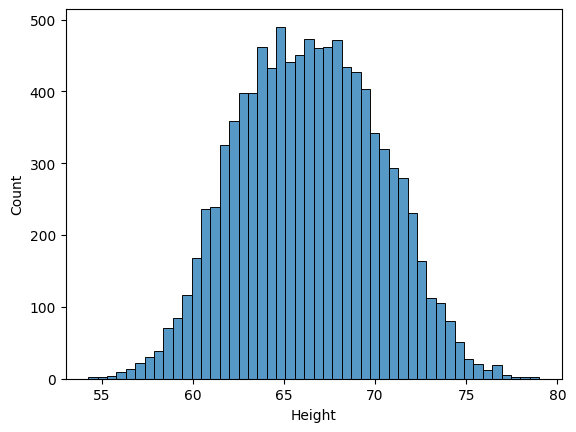

In [ ]:
height = df_hw["Height"]
sns.histplot(height)

In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1v48RRtiivufSX4ewrMaxsADK73GnN2kI -O waiting_time.csv

--2025-01-08 17:02:49--  https://drive.google.com/uc?id=1v48RRtiivufSX4ewrMaxsADK73GnN2kI
Resolving drive.google.com (drive.google.com)... 173.194.194.101, 173.194.194.102, 173.194.194.100, ...
Connecting to drive.google.com (drive.google.com)|173.194.194.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1v48RRtiivufSX4ewrMaxsADK73GnN2kI [following]
--2025-01-08 17:02:49--  https://drive.usercontent.google.com/download?id=1v48RRtiivufSX4ewrMaxsADK73GnN2kI
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 209.85.200.132, 2607:f8b0:4001:c16::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|209.85.200.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1656272 (1.6M) [application/octet-stream]
Saving to: ‘waiting_time.csv’

waiting_time.csv    100%[===================>]   1.58M  --.-KB/s    in 0.009s  

2025-01-08 17:02:52 (169 

In [ ]:
path = '/content/waiting_time.csv'
df_wt = pd.read_csv(path)

df_wt.head()

,time
0,184.003075
1,36.721521
2,29.970417
3,75.640285
4,61.489439


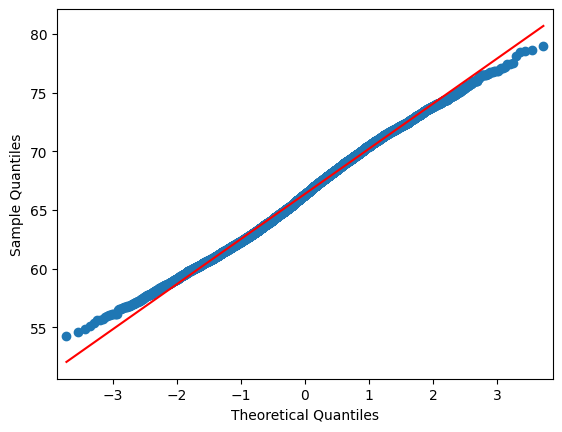

In [ ]:
qqplot(height, line="s")
plt.show()

<Axes: xlabel='time', ylabel='Count'>

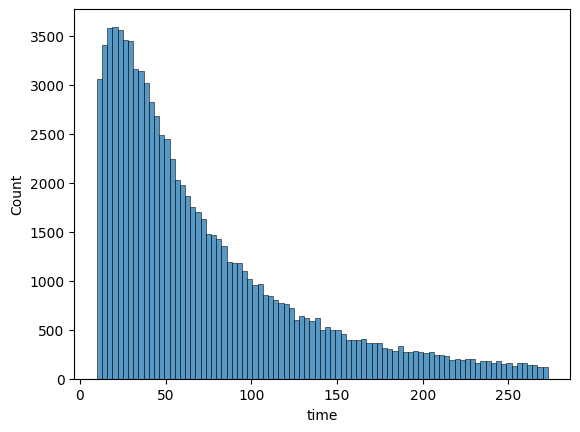

In [ ]:
sns.histplot(df_wt["time"])

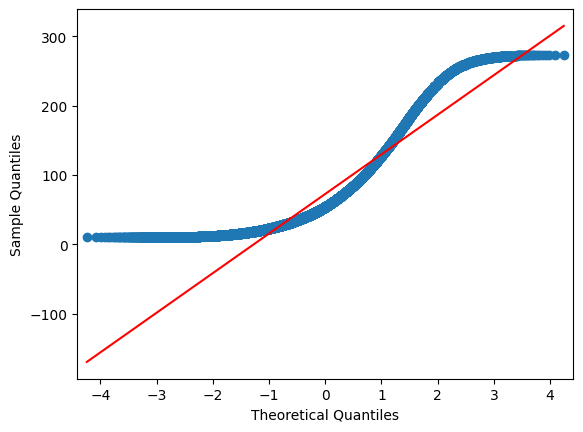

In [ ]:
qqplot(df_wt["time"], line="s")
plt.show()

In [ ]:
from scipy.stats import shapiro # Test Gaussian (50 to 200 samples)

In [ ]:
np.random.sample(42)
height_subset = df_hw["Height"].sample(100)

In [ ]:
# H0: Data is Gaussian
# Ha: Data is not Gaussian
test_stat, p_value = shapiro(height_subset)
print(p_value)

0.022102340453467092


In [ ]:
if p_value < 0.05:
    print("Reject H0")
    print("Data is not Gaussian")
else:
    print("Fail to reject H0")
    print("Data is Gaussian")

Reject H0
Data is not Gaussian


<Axes: xlabel='Height', ylabel='Count'>

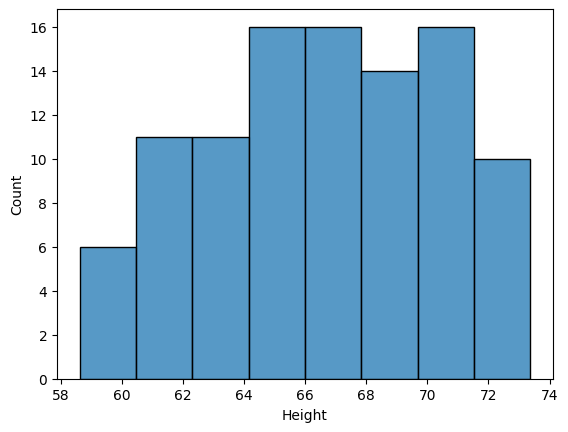

In [ ]:
sns.histplot(height_subset)

In [ ]:
np.random.sample(42)
df_wt_subset = df_wt.sample(50)["time"]

In [ ]:
# H0: Data is Gaussian
# Ha: Data is not Gaussian
test_stat, p_value = shapiro(df_wt_subset)
print(p_value)

3.34208645268681e-05


In [ ]:
if p_value < 0.05:
    print("Reject H0")
    print("Data is not Gaussian")
else:
    print("Fail to reject H0")
    print("Data is Gaussian")

Reject H0
Data is not Gaussian


In [ ]:
# H0: Data is Gaussian
# Ha: Data is not Gaussian
test_stat, p_value = shapiro(df_hw["Height"])
print(p_value)

8.162481039405506e-16


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
if p_value < 0.05:
    print("Reject H0")
    print("Data is not Gaussian")
else:
    print("Fail to reject H0")
    print("Data is Gaussian")

Reject H0
Data is not Gaussian


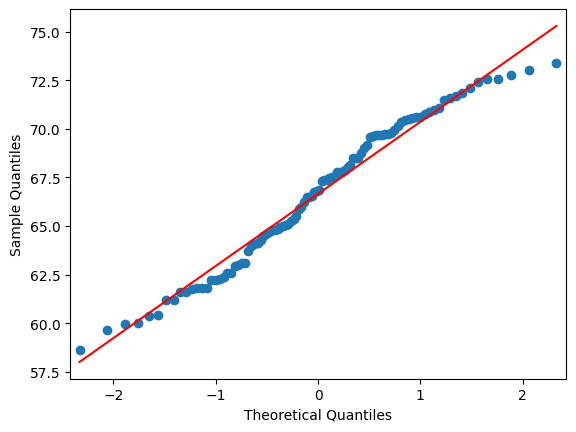

In [ ]:
qqplot(height_subset, line="s")
plt.show()

In [ ]:
from scipy.stats import levene # Test variance

<Axes: xlabel='Height', ylabel='Count'>

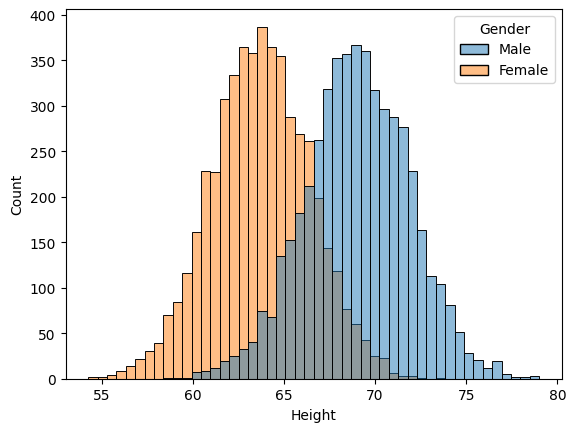

In [ ]:
sns.histplot(data=df_hw, x="Height", hue="Gender")

In [ ]:
height_men = df_hw[df_hw["Gender"]=="Male"]["Height"]
height_women = df_hw[df_hw["Gender"]=="Female"]["Height"]

In [ ]:
print("Mean of men height:",height_men.mean() , "Mean of women height:",height_women.mean())

Mean of men height: 69.02634590621741 Mean of women height: 63.70877360342507


In [ ]:
print("Variance of men height:",height_men.var() , "Variance of women height:",height_women.var())

Variance of men height: 8.19884325252049 Variance of women height: 7.269947493670132


In [ ]:
# H0: Variances are equal
# Ha: Variances are not equal
levene_stat, p_value = levene(height_men, height_women)
if p_value < 0.05:
    print("Variances are not equal")

Variances are not equal


In [ ]:
# H0: Variances are equal
# Ha: Variances are not equal
levene_stat, p_value = levene(income_kp281, income_kp481)
if p_value < 0.05:
  print("Variances are not equal")
else:
  print("Variances are equal")

Variances are equal


In [ ]:
# H0: Variances are equal
# Ha: Variances are not equal
levene_stat, p_value = levene(income_kp281, income_kp481, income_kp781)
if p_value < 0.05:
  print("Variances are not equal")
else:
  print("Variances are equal")

Variances are not equal
